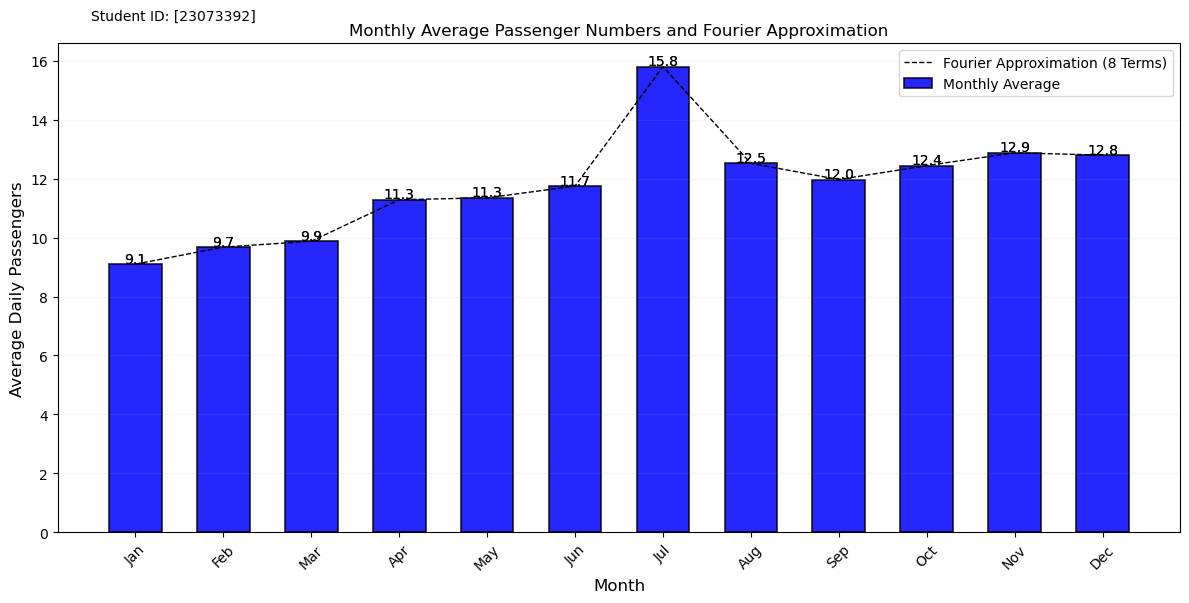

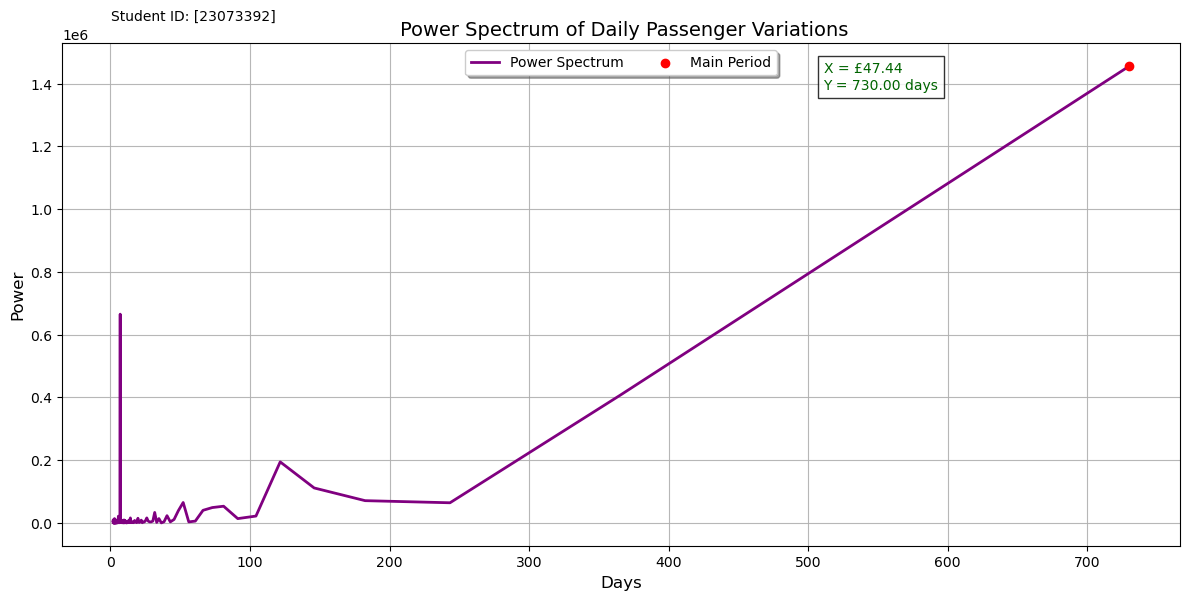

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

data = pd.read_csv('airline9.csv')
data

# Convert Date to datetime and extract Month
data['Date'] = pd.to_datetime(data['Date'])
data['Month'] = data['Date'].dt.month

# Fourier Transform of daily passenger numbers
passenger_numbers = data['Number'].values
fourier_transform = np.fft.fft(passenger_numbers)
frequencies = np.fft.fftfreq(len(passenger_numbers), d=1)


def fourier_series_approximation(x, coeffs):
    """
    Fourier series approximation
    """
    n = len(coeffs)
    approx = np.real(coeffs[0]) / len(passenger_numbers)  
    for k in range(1, n):
        approx += (2 / len(passenger_numbers)) * np.real(coeffs[k]) * np.cos(2 * np.pi * k * x / len(passenger_numbers))
        approx += (2 / len(passenger_numbers)) * np.imag(coeffs[k]) * np.sin(2 * np.pi * k * x / len(passenger_numbers))
    return approx

# Monthly average calculation
monthly_avg = data.groupby('Month')['Number'].mean()

# Fourier approximation (8 terms)
x_values = np.arange(len(passenger_numbers))
fourier_approx = fourier_series_approximation(x_values, fourier_transform[:8])

# Plot Figure 1
plt.figure(figsize=(12, 6))

# Monthly average bar chart
months = np.arange(1, 13)

plt.bar(months, monthly_avg, color='blue', edgecolor='black', linewidth=1.2, alpha=0.85, width=0.6, label='Monthly Average')

plt.grid(axis='y', linestyle='--', alpha=0.7)
for i, val in enumerate(monthly_avg):
    plt.text(i + 1, val + 0.05, f'{val:.1f}', ha='center', fontsize=10)
# Fourier approximation

plt.plot(np.linspace(1, 12, 1000),np.interp(np.linspace(1, 12, 1000), months, monthly_avg), label='Fourier Approximation (8 Terms)',color='black',linewidth=1,linestyle='--')

# Customization of Fig 1
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Daily Passengers', fontsize=12)
plt.title('Monthly Average Passenger Numbers and Fourier Approximation', fontsize=12)
plt.xticks(months, ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='-', alpha=0.1)
for i, val in enumerate(monthly_avg):
    plt.text(i + 1, val + 0.05, f'{val:.1f}', ha='center', fontsize=10)
plt.tight_layout()
plt.text(0.5, max(monthly_avg) * 1.1, 'Student ID: [23073392]', fontsize=10, color='black')
plt.savefig("Fig1")
plt.show()


# Power spectrum
power_spectrum = np.abs(fourier_transform)**2
positive_frequencies = frequencies[frequencies > 0]
positive_powers = power_spectrum[frequencies > 0]

# Main period (Y)
main_period_index = np.argmax(positive_powers)
main_period = 1 / positive_frequencies[main_period_index]  # Period in days

# Average ticket price for 2022 
avg_ticket_price_2022 = data[data['Date'].dt.year == 2022]['Price'].mean()

# Plotting Figure 2
plt.figure(figsize=(12, 6))
plt.plot(1 / positive_frequencies, positive_powers, label='Power Spectrum', color='purple', linewidth=2)
plt.scatter([main_period], [positive_powers[main_period_index]], color='red', label='Main Period', zorder=5)

#  X and Y
annotation_text = f"X = £{avg_ticket_price_2022:.2f}\nY = {main_period:.2f} days"
plt.text(0.7 * main_period,max(positive_powers) * 0.95,annotation_text, fontsize=10, color='darkgreen', bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))


#  Figure 2
plt.xlabel('Days', fontsize=12)
plt.ylabel('Power', fontsize=12)
plt.title(' Power Spectrum of Daily Passenger Variations', fontsize=14)
plt.legend(loc='upper center', fancybox=True, shadow=True, ncol=2)
plt.grid(alpha=0.9)
plt.tight_layout()


plt.text(0.5, max(positive_powers) *1.1, 'Student ID: [23073392]', fontsize=10, color='black')
plt.savefig("fig2")
plt.show()


